# Evaluasi AI-1 (`bacaStruk`) — JEJAK

**Ini bukan notebook training.** Tidak ada model yang dilatih atau bobot yang diubah di sini.
Yang terjadi: kode produksi `bacaStruk` (`services/verifier/ai.ts`, dipanggil Claude API,
zero-shot) dijalankan atas sampel struk dari dataset publik
[SROIE v2](https://www.kaggle.com/datasets/urbikn/sroie-datasetv2) (ICDAR 2019), lalu hasilnya
dibandingkan ke label ground-truth resmi dataset itu.

Notebook ini **tidak memanggil AI apa pun** — cuma membaca `results/hasil-eval.json` yang
sudah dihasilkan `run-eval.ts`. Jadi buka-tutup/ubah grafik di sini nol biaya token.

Keterbatasan yang jujur perlu disebut: SROIE adalah struk scan rapi berbahasa Inggris —
bukan struk termal miring/pudar berbahasa Jepang/Korea/Mandarin/Thailand yang jadi kasus
tersulit JEJAK sesungguhnya (lihat `INSTRUKSI_STRUK` di `ai.ts`). Evaluasi ini membuktikan
*pipeline*-nya bekerja dan terukur — bukan klaim ketahanan penuh terhadap struk asli jastip.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

with open(Path("results") / "hasil-eval.json") as f:
    hasil = json.load(f)

df = pd.json_normalize(hasil)
df = df.rename(columns={
    "file": "berkas",
    "groundTruth.total": "totalAsli",
    "prediksi.nominal": "totalPrediksi",
    "prediksi.keyakinan": "keyakinan",
    "prediksi.sumber": "sumber",
    "cocokTotal": "cocokTotal",
    "cocokTanggal": "cocokTanggal"
})
df[["berkas", "totalAsli", "totalPrediksi", "cocokTotal", "cocokTanggal", "keyakinan", "sumber"]]

,berkas,totalAsli,totalPrediksi,cocokTotal,cocokTanggal,keyakinan,sumber
0,X00016469670.jpg,193.00,193.00,True,True,0.95,ai
1,X00016469671.jpg,170.00,170.00,True,True,0.90,ai
2,X51005200931.jpg,436.20,436.20,True,True,0.90,ai
3,X51005230605.jpg,4.90,4.90,True,True,0.90,ai
4,X51005230616.jpg,38.90,38.90,True,True,0.60,ai
5,X51005230621.jpg,7.30,7.30,True,True,0.90,ai
6,X51005230648.jpg,6.35,6.35,True,True,0.90,ai
7,X51005230657.jpg,7.95,7.95,True,True,0.55,ai


In [2]:
n = len(df)
ringkasan = pd.Series({
    "Struk diuji": n,
    "Akurasi total (%)": round(df["cocokTotal"].mean() * 100, 1),
    "Akurasi tanggal (%)": round(df["cocokTanggal"].mean() * 100, 1),
    "Rata-rata keyakinan": round(df["keyakinan"].mean(), 3),
    "Semua panggilan mode": ", ".join(df["sumber"].unique()),
    "Perkiraan total biaya (USD)": round(df["perkiraanBiayaUsd"].sum(), 4)
})
ringkasan

Struk diuji                         8
Akurasi total (%)               100.0
Akurasi tanggal (%)             100.0
Rata-rata keyakinan             0.825
Semua panggilan mode               ai
Perkiraan total biaya (USD)    0.0317
dtype: object

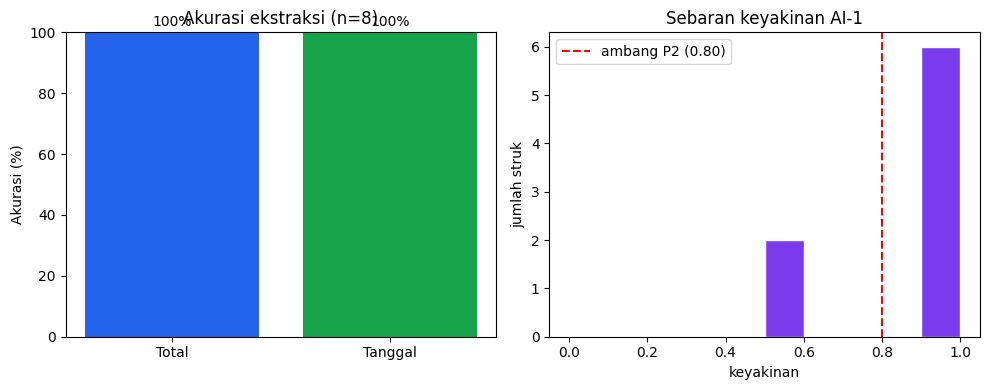

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

metrik = ["cocokTotal", "cocokTanggal"]
akurasi = [df[m].mean() * 100 for m in metrik]
axes[0].bar(["Total", "Tanggal"], akurasi, color=["#2563eb", "#16a34a"])
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Akurasi (%)")
axes[0].set_title(f"Akurasi ekstraksi (n={n})")
for i, v in enumerate(akurasi):
    axes[0].text(i, v + 2, f"{v:.0f}%", ha="center")

axes[1].hist(df["keyakinan"], bins=10, range=(0, 1), color="#7c3aed", edgecolor="white")
axes[1].axvline(0.80, color="red", linestyle="--", label="ambang P2 (0.80)")
axes[1].set_xlabel("keyakinan")
axes[1].set_ylabel("jumlah struk")
axes[1].set_title("Sebaran keyakinan AI-1")
axes[1].legend()

plt.tight_layout()
plt.show()

## Catatan

- Garis putus merah pada histogram adalah `AI_CONFIDENCE_THRESHOLD` di `.env` (§ Pagar 1
  `decision.ts`) — struk dengan keyakinan di bawah garis ini TIDAK dicairkan otomatis,
  diteruskan ke arbiter. Ini P2: AI hanya boleh menahan, tidak melonggarkan.
- Sampel di sini kecil (lihat `n` di ringkasan) — cukup untuk membuktikan pipeline jalan
  dan terukur, belum cukup untuk klaim akurasi statistik yang kuat. Perbesar sampel dengan
  `npx tsx run-eval.ts <n>` — struk yang sudah di-cache tidak akan memanggil API lagi.